In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_style("white")
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch as pt
import Levenshtein as lev
from umap import UMAP
import umap.plot

/doctorai/marinafr/progs/miniconda3/envs/airr_atlas/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load ireceptor metadata df
ireceptor_metadata = pd.read_csv(f'<UPDATE_PATH>'  # TODO: update path to your data, sep=';')
columns_to_keep = ['v_call', 'j_call', 'd_call', 'c_call', 'junction_aa', 'id', 'duplicate_count', 'repertoire_id']
columns_to_drop = ireceptor_metadata.columns.difference(columns_to_keep)
ireceptor_metadata = ireceptor_metadata.drop(columns=columns_to_drop)
ireceptor_metadata['dataset'] = 'ireceptor'
ireceptor_metadata['junction_length'] = ireceptor_metadata['junction_aa'].apply(len)

ireceptor_metadata['v_family'] = ireceptor_metadata['v_call'].str.split(r'[-/S ]').str[0]
ireceptor_metadata['d_family'] = ireceptor_metadata['d_call'].str.split(r'[-/ ]').str[0]
ireceptor_metadata['j_family'] = ireceptor_metadata['j_call'].str.split(r'[-*/ ]').str[0]

ireceptor_metadata['v_family'].fillna('nan', inplace=True)
ireceptor_metadata['d_family'].fillna('nan', inplace=True)
ireceptor_metadata['j_family'].fillna('nan', inplace=True)

ireceptor_metadata

,v_call,d_call,j_call,c_call,junction_aa,duplicate_count,repertoire_id,id,dataset,junction_length,v_family,d_family,j_family
0,IGHV3-23*01,IGHD3-16*01,IGHJ4*02,IgM,CAKCGDGIYADYYFDYW,NaN,4941241542787076586-242ac113-0001-012,1,ireceptor,17,IGHV3,IGHD3,IGHJ4
1,IGHV3-30*18,IGHD4-17*01,IGHJ4*02,IgM,CAKGGGTVTTGGFDYW,NaN,4250138355187716586-242ac113-0001-012,2,ireceptor,16,IGHV3,IGHD4,IGHJ4
2,IGHV3-23*01,IGHD3-22*01,IGHJ5*02,IgM,CAKDSSAWSKDSW,NaN,401804708298756586-242ac113-0001-012,3,ireceptor,13,IGHV3,IGHD3,IGHJ5
3,IGHV4-59*10,IGHD3-22*01,IGHJ4*02,IgM,CARETYYYDSSGYYINYFDYW,NaN,1025069326778428950-242ac113-0001-012,4,ireceptor,21,IGHV4,IGHD3,IGHJ4
4,IGHV4-31*03,IGHD3-10*01,IGHJ4*02,IgM,CAREGVNRTWFGELSPPYFDYW,NaN,2690893428047876586-242ac113-0001-012,5,ireceptor,22,IGHV4,IGHD3,IGHJ4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
799995,IGHV1-8*02,IGHD3-22*01,IGHJ4*02,IgM,CARGTIAVANDYW,NaN,1279975635796028950-242ac113-0001-012,799996,ireceptor,13,IGHV1,IGHD3,IGHJ4
799996,IGHV3-30*04,IGHD3-16*01,IGHJ3*02,IgG1,CARVPDFGELQLFAYDIW,NaN,667104838172676586-242ac113-0001-012,799997,ireceptor,18,IGHV3,IGHD3,IGHJ3
799997,IGHV4-59*01,IGHD3-10*02,IGHJ4*02,IgM,CARASVLLSADFW,NaN,1137382721568828950-242ac113-0001-012,799998,ireceptor,13,IGHV4,IGHD3,IGHJ4
799998,IGHV1-2*03,IGHD2-8*02,IGHJ4*02,IgM,CARVRVVNSKAFDYW,NaN,891281095508028950-242ac113-0001-012,799999,ireceptor,15,IGHV1,IGHD2,IGHJ4


# **ESM2**

In [4]:
model_name = 'esm2'

if model_name == 'antiberta2':
    short_model_name = 'ab2'
else: 
    short_model_name = model_name


umap_filtered = pd.DataFrame(pd.read_pickle(f'<UPDATE_PATH>'  # TODO: update path to your data).values)
umap_filtered.columns = ['x', 'y']
umap_filtered['id'] = range(1, len(umap_filtered) + 1)

esm2_df = pd.merge(ireceptor_metadata, umap_filtered, on='id')

esm2_df

,v_call,d_call,j_call,c_call,junction_aa,duplicate_count,repertoire_id,id,dataset,junction_length,v_family,d_family,j_family,x,y
0,IGHV3-23*01,IGHD3-16*01,IGHJ4*02,IgM,CAKCGDGIYADYYFDYW,NaN,4941241542787076586-242ac113-0001-012,1,ireceptor,17,IGHV3,IGHD3,IGHJ4,-0.094642,5.544011
1,IGHV3-30*18,IGHD4-17*01,IGHJ4*02,IgM,CAKGGGTVTTGGFDYW,NaN,4250138355187716586-242ac113-0001-012,2,ireceptor,16,IGHV3,IGHD4,IGHJ4,0.559437,13.420984
2,IGHV3-23*01,IGHD3-22*01,IGHJ5*02,IgM,CAKDSSAWSKDSW,NaN,401804708298756586-242ac113-0001-012,3,ireceptor,13,IGHV3,IGHD3,IGHJ5,-2.368691,10.560768
3,IGHV4-59*10,IGHD3-22*01,IGHJ4*02,IgM,CARETYYYDSSGYYINYFDYW,NaN,1025069326778428950-242ac113-0001-012,4,ireceptor,21,IGHV4,IGHD3,IGHJ4,0.261434,4.070134
4,IGHV4-31*03,IGHD3-10*01,IGHJ4*02,IgM,CAREGVNRTWFGELSPPYFDYW,NaN,2690893428047876586-242ac113-0001-012,5,ireceptor,22,IGHV4,IGHD3,IGHJ4,1.923337,7.821213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799995,IGHV1-8*02,IGHD3-22*01,IGHJ4*02,IgM,CARGTIAVANDYW,NaN,1279975635796028950-242ac113-0001-012,799996,ireceptor,13,IGHV1,IGHD3,IGHJ4,2.065004,12.915748
799996,IGHV3-30*04,IGHD3-16*01,IGHJ3*02,IgG1,CARVPDFGELQLFAYDIW,NaN,667104838172676586-242ac113-0001-012,799997,ireceptor,18,IGHV3,IGHD3,IGHJ3,1.248885,10.099935
799997,IGHV4-59*01,IGHD3-10*02,IGHJ4*02,IgM,CARASVLLSADFW,NaN,1137382721568828950-242ac113-0001-012,799998,ireceptor,13,IGHV4,IGHD3,IGHJ4,1.993298,11.007856
799998,IGHV1-2*03,IGHD2-8*02,IGHJ4*02,IgM,CARVRVVNSKAFDYW,NaN,891281095508028950-242ac113-0001-012,799999,ireceptor,15,IGHV1,IGHD2,IGHJ4,0.846901,11.575349


In [24]:
umap_filtered = pd.DataFrame(pd.read_pickle(f'<UPDATE_PATH>'  # TODO: update path to your data).values)
umap_filtered.columns = ['x', 'y']
umap_filtered['id'] = range(1, len(umap_filtered) + 1)

esm2_random_df = pd.merge(ireceptor_metadata, umap_filtered, on='id')

esm2_random_df

,v_call,d_call,j_call,c_call,junction_aa,duplicate_count,repertoire_id,id,dataset,junction_length,v_family,d_family,j_family,x,y
0,IGHV3-23*01,IGHD3-16*01,IGHJ4*02,IgM,CAKCGDGIYADYYFDYW,NaN,4941241542787076586-242ac113-0001-012,1,ireceptor,17,IGHV3,IGHD3,IGHJ4,7.502887,-0.186054
1,IGHV3-30*18,IGHD4-17*01,IGHJ4*02,IgM,CAKGGGTVTTGGFDYW,NaN,4250138355187716586-242ac113-0001-012,2,ireceptor,16,IGHV3,IGHD4,IGHJ4,12.520093,-1.309221
2,IGHV3-23*01,IGHD3-22*01,IGHJ5*02,IgM,CAKDSSAWSKDSW,NaN,401804708298756586-242ac113-0001-012,3,ireceptor,13,IGHV3,IGHD3,IGHJ5,9.444608,1.176942
3,IGHV4-59*10,IGHD3-22*01,IGHJ4*02,IgM,CARETYYYDSSGYYINYFDYW,NaN,1025069326778428950-242ac113-0001-012,4,ireceptor,21,IGHV4,IGHD3,IGHJ4,8.401932,1.161007
4,IGHV4-31*03,IGHD3-10*01,IGHJ4*02,IgM,CAREGVNRTWFGELSPPYFDYW,NaN,2690893428047876586-242ac113-0001-012,5,ireceptor,22,IGHV4,IGHD3,IGHJ4,7.703419,2.664620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
789995,IGHV1-2*03,IGHD3-3*01,IGHJ6*03,IgM,CARDRYYDFWSGYYIPYYYYYMDVW,NaN,4684015951429636586-242ac113-0001-012,789996,ireceptor,25,IGHV1,IGHD3,IGHJ6,10.122452,-2.501793
789996,IGHV3-21*02,IGHD2-2*01,IGHJ4*02,IgM,CARVGLFCSSAICYDDYW,NaN,2892713941286916586-242ac113-0001-012,789997,ireceptor,18,IGHV3,IGHD2,IGHJ4,10.670381,1.456826
789997,IGHV4-39*07,IGHD2-2*01,IGHJ4*02,IgG1,CARVTGLLASQGLDFW,NaN,1279975635796028950-242ac113-0001-012,789998,ireceptor,16,IGHV4,IGHD2,IGHJ4,9.066647,5.652948
789998,IGHV4-59*01,IGHD1-26*01,IGHJ6*02,IgM,CARLVYWSRSHYYGMDVW,NaN,3062236300460036586-242ac113-0001-012,789999,ireceptor,18,IGHV4,IGHD1,IGHJ6,8.144192,0.557797


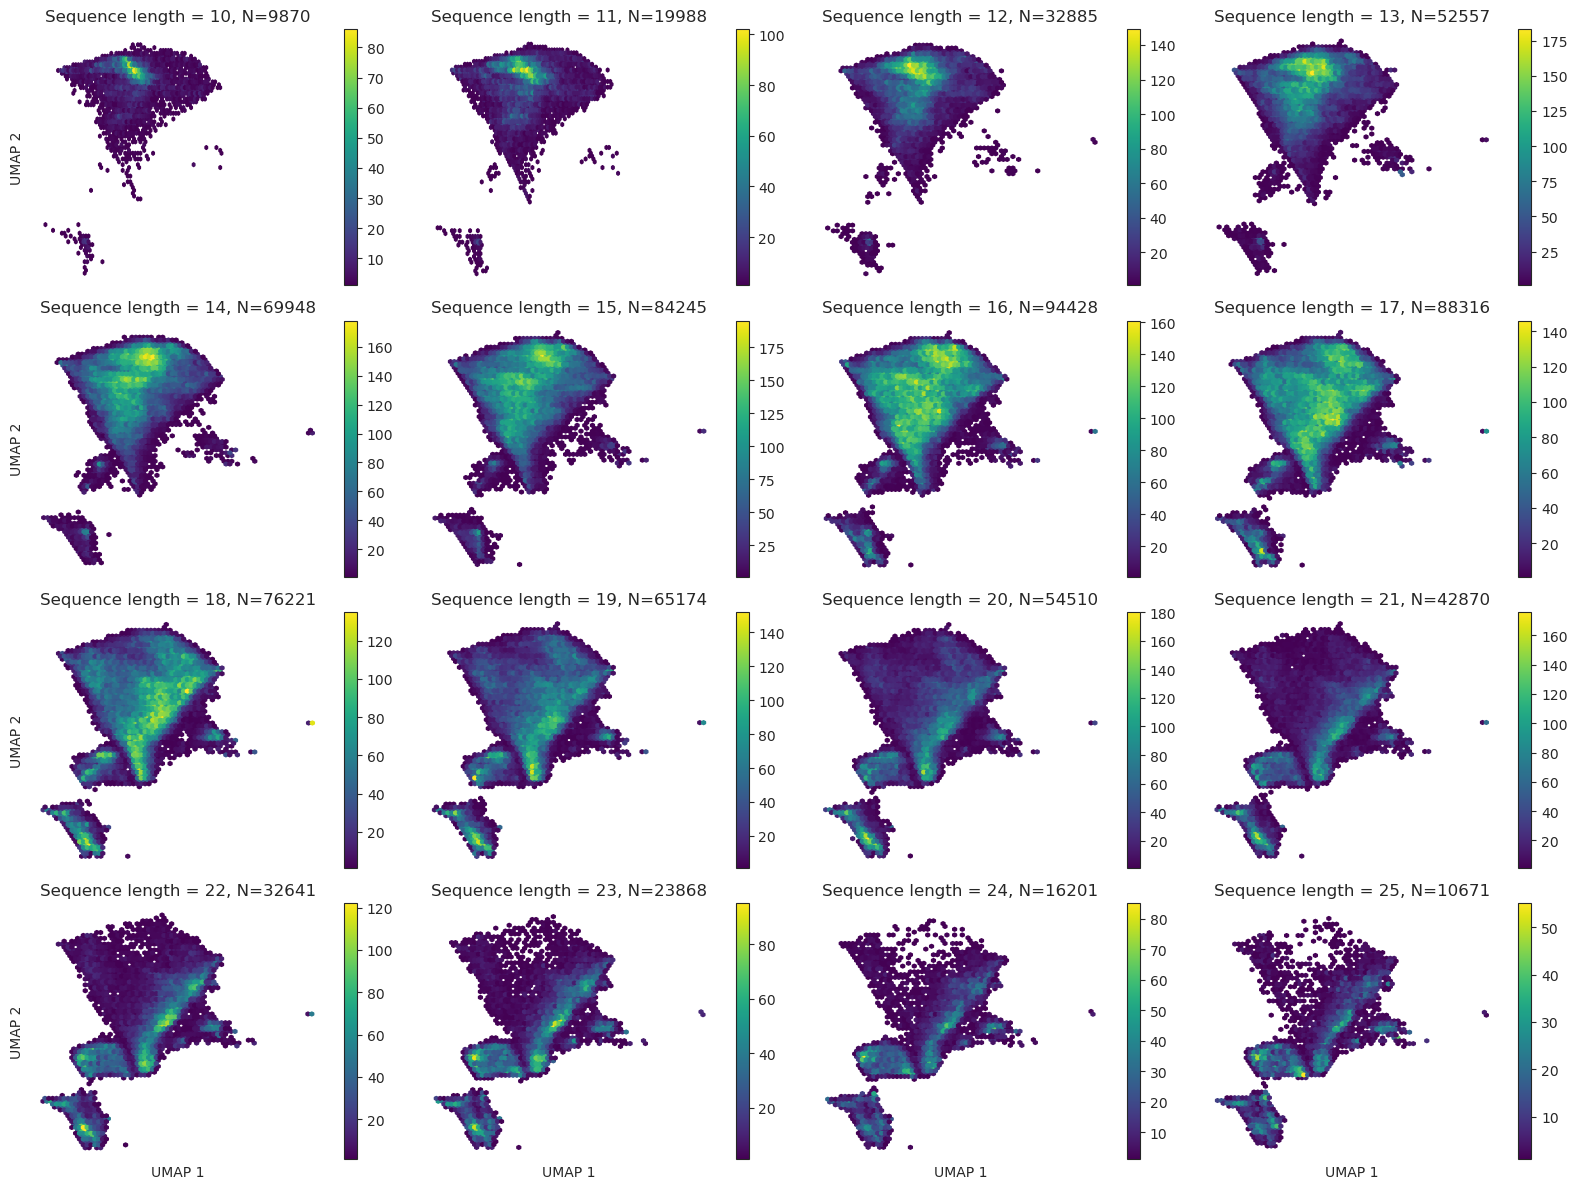

In [11]:
cutoff_values = np.arange(10, 26, 1)
label = 'junction_length'

x_dim = 4
y_dim = 4
alpha = 0.05
gridsize = 70  # Adjust the gridsize as needed

fig, axes = plt.subplots(y_dim, x_dim, figsize=(16, 12), sharex='col', sharey='row')

c = 0

# Loop through the cutoff values and create hexbin plots
for i in range(y_dim):
    for j in range(x_dim):
        cutoff = cutoff_values[c]
        c += 1

        ax = axes[i, j]
        x_data = esm2_df[esm2_df[label] == cutoff]['x']
        y_data = esm2_df[esm2_df[label] == cutoff]['y']

        hb = ax.hexbin(x_data, y_data, gridsize=gridsize, mincnt=1, cmap='viridis')
        num_data_points = len(x_data)
        ax.set_title(f'Sequence length = {cutoff}, N={num_data_points}', fontsize=12)
        plt.colorbar(hb, ax=ax)  # Add colorbar

        # Remove axis numbers and ticks
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xticklabels([])
        ax.set_yticklabels([])

# Add labels to the axes
for i in range(x_dim):
    axes[x_dim-1, i].set_xlabel('UMAP 1', fontsize=10)
    axes[i, 0].set_ylabel('UMAP 2', fontsize=10)

# Remove the spines
sns.despine(left=True, bottom=True)

# Adjust spacing between subplots
plt.tight_layout()

plt.savefig(f'{model_name}_ireceptor_hexbin_sep_by_{label}.png')

# Show the plot
plt.show()

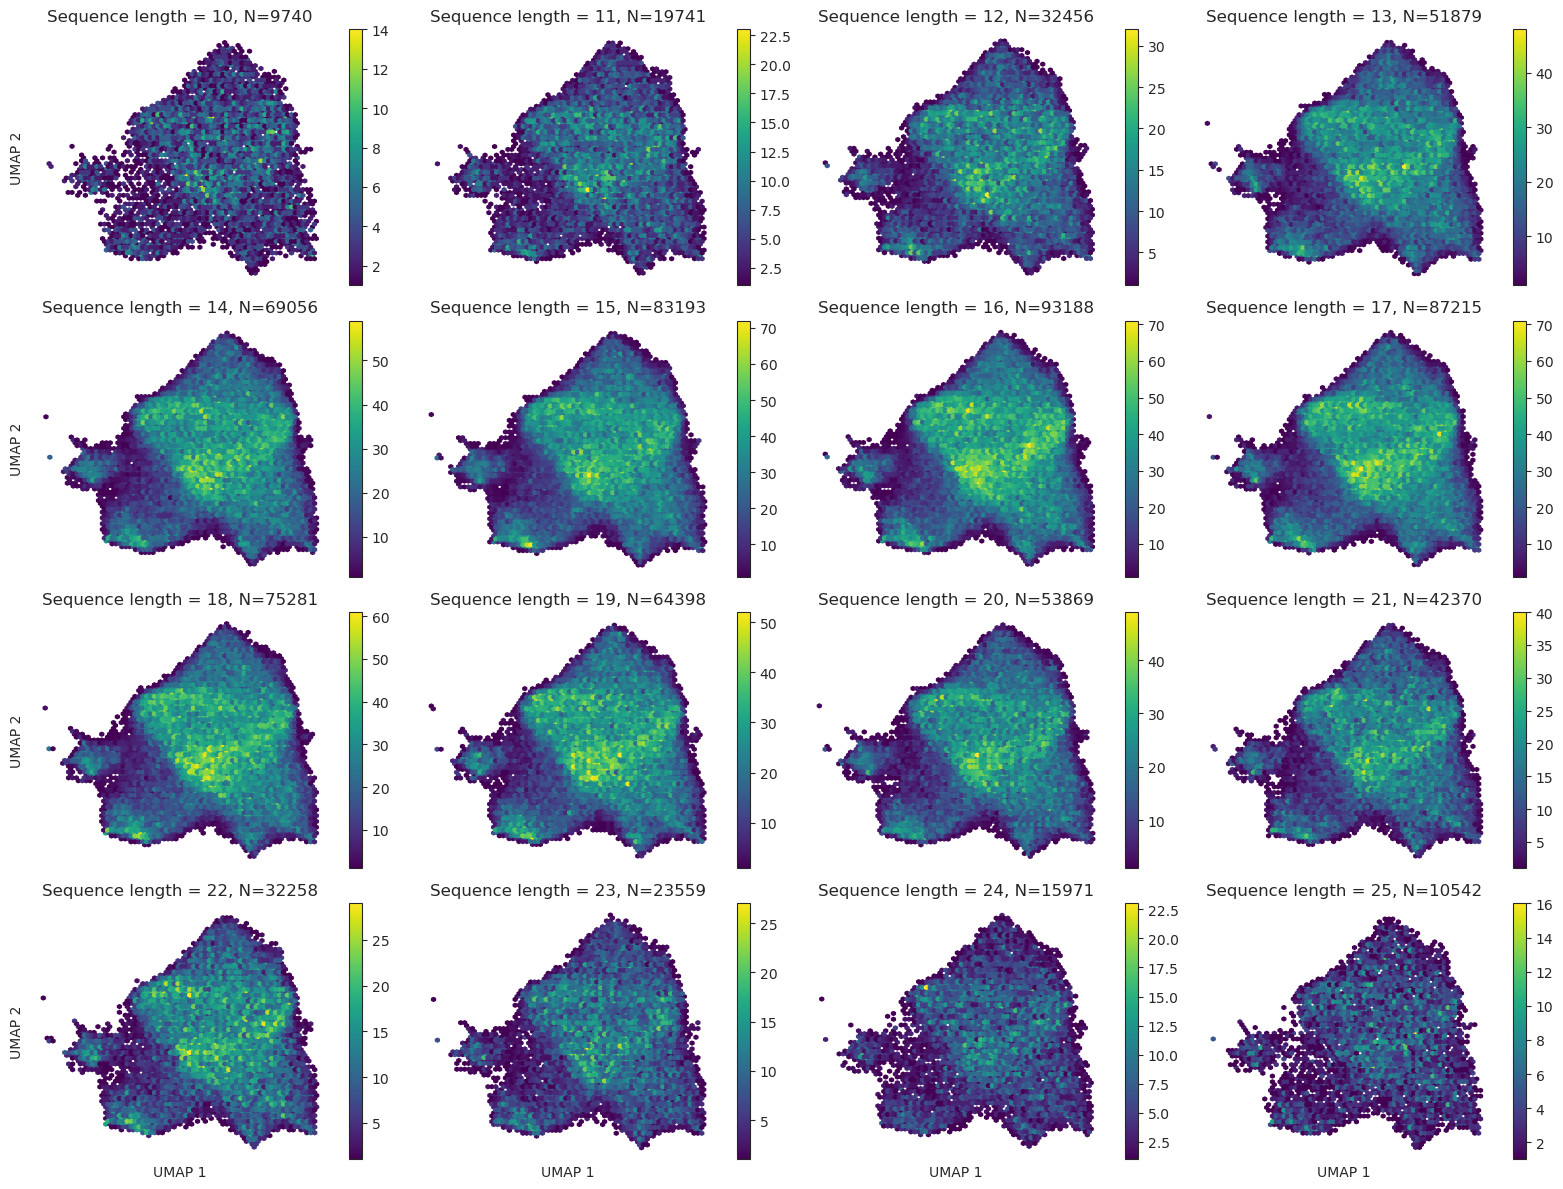

In [25]:
cutoff_values = np.arange(10, 26, 1)
label = 'junction_length'

x_dim = 4
y_dim = 4
alpha = 0.05
gridsize = 70  # Adjust the gridsize as needed

fig, axes = plt.subplots(y_dim, x_dim, figsize=(16, 12), sharex='col', sharey='row')

c = 0

# Loop through the cutoff values and create hexbin plots
for i in range(y_dim):
    for j in range(x_dim):
        cutoff = cutoff_values[c]
        c += 1

        ax = axes[i, j]
        x_data = esm2_random_df[esm2_random_df[label] == cutoff]['x']
        y_data = esm2_random_df[esm2_random_df[label] == cutoff]['y']

        hb = ax.hexbin(x_data, y_data, gridsize=gridsize, mincnt=1, cmap='viridis')
        num_data_points = len(x_data)
        ax.set_title(f'Sequence length = {cutoff}, N={num_data_points}', fontsize=12)
        plt.colorbar(hb, ax=ax)  # Add colorbar

        # Remove axis numbers and ticks
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xticklabels([])
        ax.set_yticklabels([])

# Add labels to the axes
for i in range(x_dim):
    axes[x_dim-1, i].set_xlabel('UMAP 1', fontsize=10)
    axes[i, 0].set_ylabel('UMAP 2', fontsize=10)

# Remove the spines
sns.despine(left=True, bottom=True)

# Adjust spacing between subplots
plt.tight_layout()

plt.savefig(f'{model_name}_random_hexbin_sep_by_{label}.png')

# Show the plot
plt.show()

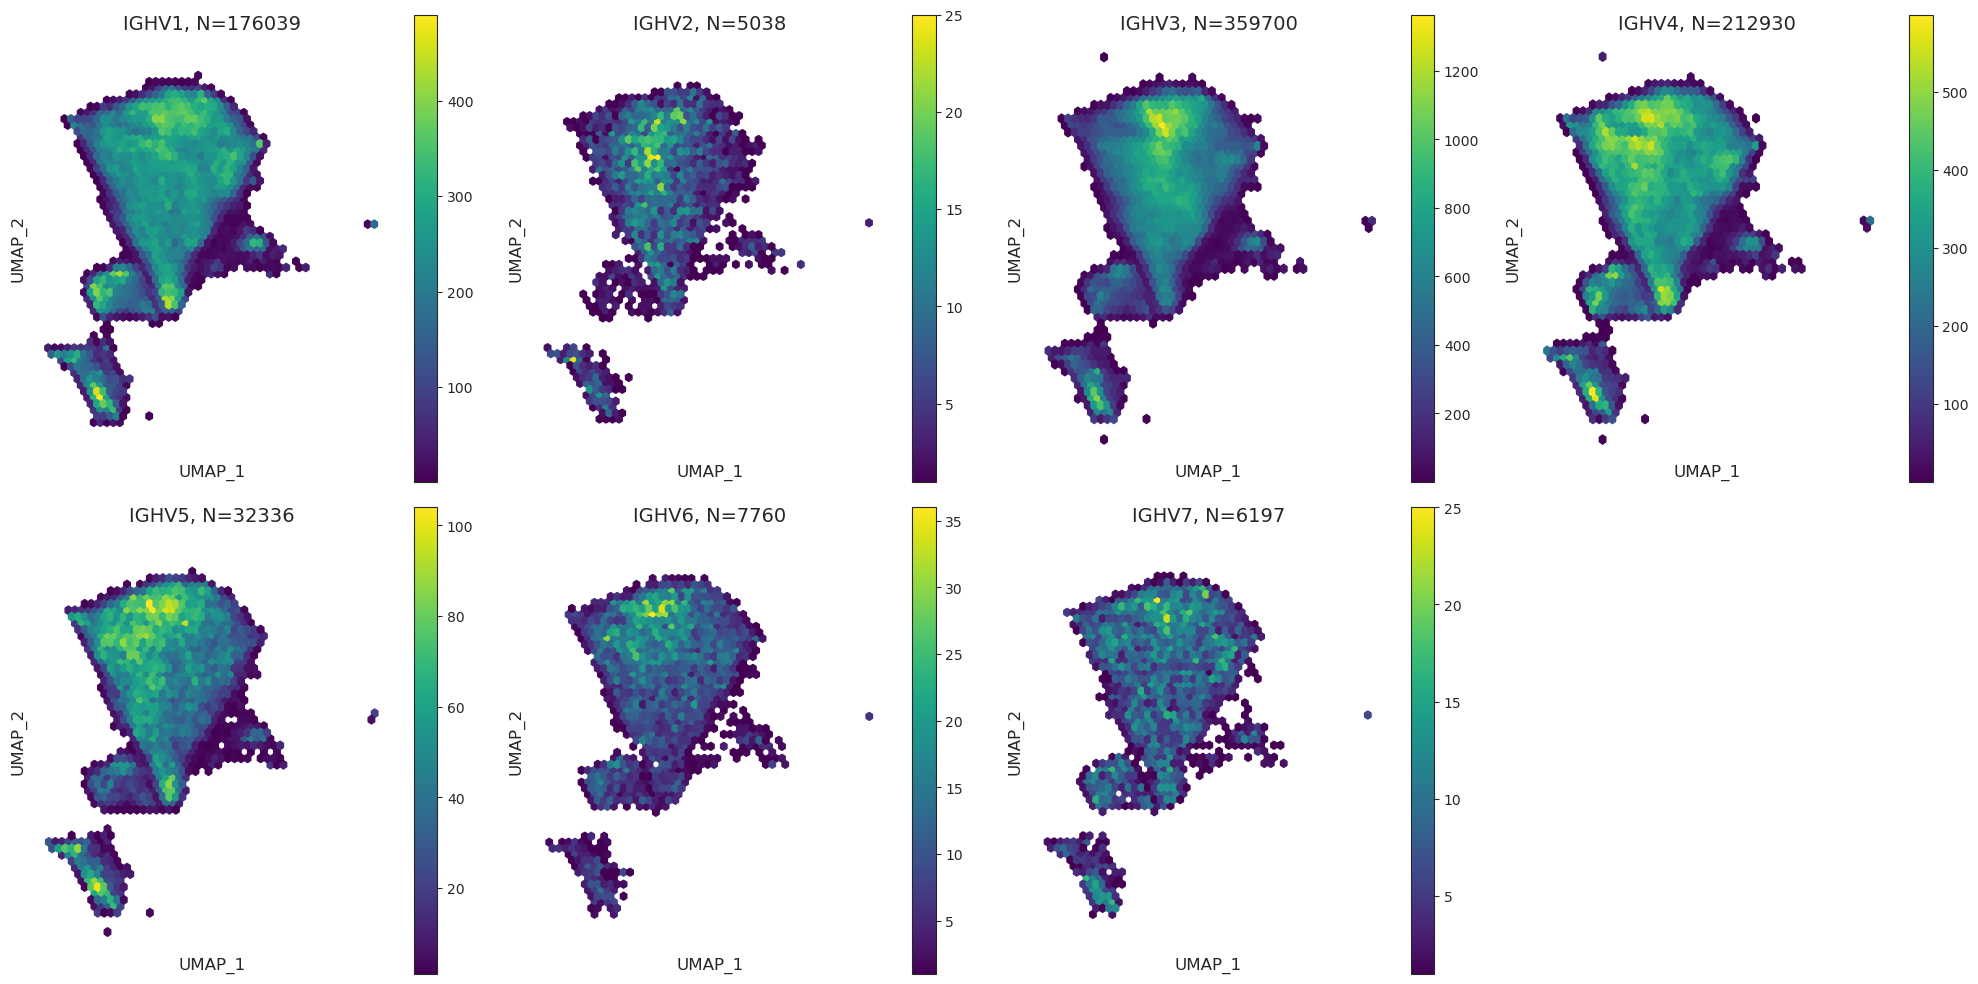

In [19]:
hue_name = 'v_family'  # column name for grouping
gridsize = 50

# --- Sort IGHV families in natural numeric order ---
# Extract the unique families and sort by their numeric suffix
unique_classes = sorted(
    esm2_df[hue_name].unique(),
    key=lambda x: int(''.join(filter(str.isdigit, x))) if any(ch.isdigit() for ch in x) else np.inf
)

# --- Grid layout ---
num_classes = len(unique_classes)
num_rows = int(num_classes ** 0.5)
num_cols = (num_classes + num_rows - 1) // num_rows

# --- Figure setup ---
fig_width = 20 if hue_name != 'j_family' else 20 * 3/4
fig_height = 20 * (num_rows / num_cols) if hue_name != 'j_family' else 20 * 3/4 * (num_rows / num_cols)
fig, axes = plt.subplots(num_rows, num_cols, figsize=(fig_width, fig_height), sharex=True, sharey=True)
axes = axes.flatten()

# --- Plot each V family ---
for i, el in enumerate(unique_classes):
    ax = axes[i]
    subset = esm2_df[esm2_df[hue_name] == el]
    x_data, y_data = subset['x'], subset['y']

    ax.set_aspect('equal')
    hb = ax.hexbin(x_data, y_data, gridsize=gridsize, mincnt=1, cmap='viridis')

    num_points = len(subset)
    ax.set_title(f'{el}, N={num_points}', fontsize=14)
    ax.set_xlabel('UMAP_1', fontsize=12)
    ax.set_ylabel('UMAP_2', fontsize=12)

    plt.colorbar(hb, ax=ax)

    # Remove axis numbers and ticks
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])

# Remove unused subplots
for i in range(num_classes, len(axes)):
    fig.delaxes(axes[i])

# Remove the spines
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig(f'{model_name}_ireceptor_hexbin_sep_by_{hue_name}.png', dpi=300)
plt.show()


# **AB2**

In [26]:
model_name = 'antiberta2'

if model_name == 'antiberta2':
    short_model_name = 'ab2'
else: 
    short_model_name = model_name


umap_filtered = pd.DataFrame(pd.read_pickle(f'<UPDATE_PATH>'  # TODO: update path to your data).values)
umap_filtered.columns = ['x', 'y']
umap_filtered['id'] = range(1, len(umap_filtered) + 1)

ab2_df = pd.merge(ireceptor_metadata, umap_filtered, on='id')

ab2_df

,v_call,d_call,j_call,c_call,junction_aa,duplicate_count,repertoire_id,id,dataset,junction_length,v_family,d_family,j_family,x,y
0,IGHV3-23*01,IGHD3-16*01,IGHJ4*02,IgM,CAKCGDGIYADYYFDYW,NaN,4941241542787076586-242ac113-0001-012,1,ireceptor,17,IGHV3,IGHD3,IGHJ4,-1.066102,1.481627
1,IGHV3-30*18,IGHD4-17*01,IGHJ4*02,IgM,CAKGGGTVTTGGFDYW,NaN,4250138355187716586-242ac113-0001-012,2,ireceptor,16,IGHV3,IGHD4,IGHJ4,0.634459,-1.678521
2,IGHV3-23*01,IGHD3-22*01,IGHJ5*02,IgM,CAKDSSAWSKDSW,NaN,401804708298756586-242ac113-0001-012,3,ireceptor,13,IGHV3,IGHD3,IGHJ5,-0.030476,3.373512
3,IGHV4-59*10,IGHD3-22*01,IGHJ4*02,IgM,CARETYYYDSSGYYINYFDYW,NaN,1025069326778428950-242ac113-0001-012,4,ireceptor,21,IGHV4,IGHD3,IGHJ4,-3.803062,2.848410
4,IGHV4-31*03,IGHD3-10*01,IGHJ4*02,IgM,CAREGVNRTWFGELSPPYFDYW,NaN,2690893428047876586-242ac113-0001-012,5,ireceptor,22,IGHV4,IGHD3,IGHJ4,2.651949,-2.136989
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799995,IGHV1-8*02,IGHD3-22*01,IGHJ4*02,IgM,CARGTIAVANDYW,NaN,1279975635796028950-242ac113-0001-012,799996,ireceptor,13,IGHV1,IGHD3,IGHJ4,-0.204544,-2.614596
799996,IGHV3-30*04,IGHD3-16*01,IGHJ3*02,IgG1,CARVPDFGELQLFAYDIW,NaN,667104838172676586-242ac113-0001-012,799997,ireceptor,18,IGHV3,IGHD3,IGHJ3,2.252355,-0.994080
799997,IGHV4-59*01,IGHD3-10*02,IGHJ4*02,IgM,CARASVLLSADFW,NaN,1137382721568828950-242ac113-0001-012,799998,ireceptor,13,IGHV4,IGHD3,IGHJ4,1.438015,-0.616875
799998,IGHV1-2*03,IGHD2-8*02,IGHJ4*02,IgM,CARVRVVNSKAFDYW,NaN,891281095508028950-242ac113-0001-012,799999,ireceptor,15,IGHV1,IGHD2,IGHJ4,-0.850816,-0.346674


In [27]:
umap_filtered = pd.DataFrame(pd.read_pickle(f'<UPDATE_PATH>'  # TODO: update path to your data).values)
umap_filtered.columns = ['x', 'y']
umap_filtered['id'] = range(1, len(umap_filtered) + 1)

ab2_random_df = pd.merge(ireceptor_metadata, umap_filtered, on='id')

ab2_random_df

,v_call,d_call,j_call,c_call,junction_aa,duplicate_count,repertoire_id,id,dataset,junction_length,v_family,d_family,j_family,x,y
0,IGHV3-23*01,IGHD3-16*01,IGHJ4*02,IgM,CAKCGDGIYADYYFDYW,NaN,4941241542787076586-242ac113-0001-012,1,ireceptor,17,IGHV3,IGHD3,IGHJ4,1.962546,1.638079
1,IGHV3-30*18,IGHD4-17*01,IGHJ4*02,IgM,CAKGGGTVTTGGFDYW,NaN,4250138355187716586-242ac113-0001-012,2,ireceptor,16,IGHV3,IGHD4,IGHJ4,2.008307,0.354452
2,IGHV3-23*01,IGHD3-22*01,IGHJ5*02,IgM,CAKDSSAWSKDSW,NaN,401804708298756586-242ac113-0001-012,3,ireceptor,13,IGHV3,IGHD3,IGHJ5,1.062884,2.449296
3,IGHV4-59*10,IGHD3-22*01,IGHJ4*02,IgM,CARETYYYDSSGYYINYFDYW,NaN,1025069326778428950-242ac113-0001-012,4,ireceptor,21,IGHV4,IGHD3,IGHJ4,5.115290,3.949658
4,IGHV4-31*03,IGHD3-10*01,IGHJ4*02,IgM,CAREGVNRTWFGELSPPYFDYW,NaN,2690893428047876586-242ac113-0001-012,5,ireceptor,22,IGHV4,IGHD3,IGHJ4,5.493928,0.531199
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
789995,IGHV1-2*03,IGHD3-3*01,IGHJ6*03,IgM,CARDRYYDFWSGYYIPYYYYYMDVW,NaN,4684015951429636586-242ac113-0001-012,789996,ireceptor,25,IGHV1,IGHD3,IGHJ6,7.296727,1.407482
789996,IGHV3-21*02,IGHD2-2*01,IGHJ4*02,IgM,CARVGLFCSSAICYDDYW,NaN,2892713941286916586-242ac113-0001-012,789997,ireceptor,18,IGHV3,IGHD2,IGHJ4,1.132577,4.777330
789997,IGHV4-39*07,IGHD2-2*01,IGHJ4*02,IgG1,CARVTGLLASQGLDFW,NaN,1279975635796028950-242ac113-0001-012,789998,ireceptor,16,IGHV4,IGHD2,IGHJ4,4.015785,1.637588
789998,IGHV4-59*01,IGHD1-26*01,IGHJ6*02,IgM,CARLVYWSRSHYYGMDVW,NaN,3062236300460036586-242ac113-0001-012,789999,ireceptor,18,IGHV4,IGHD1,IGHJ6,1.312149,3.056028


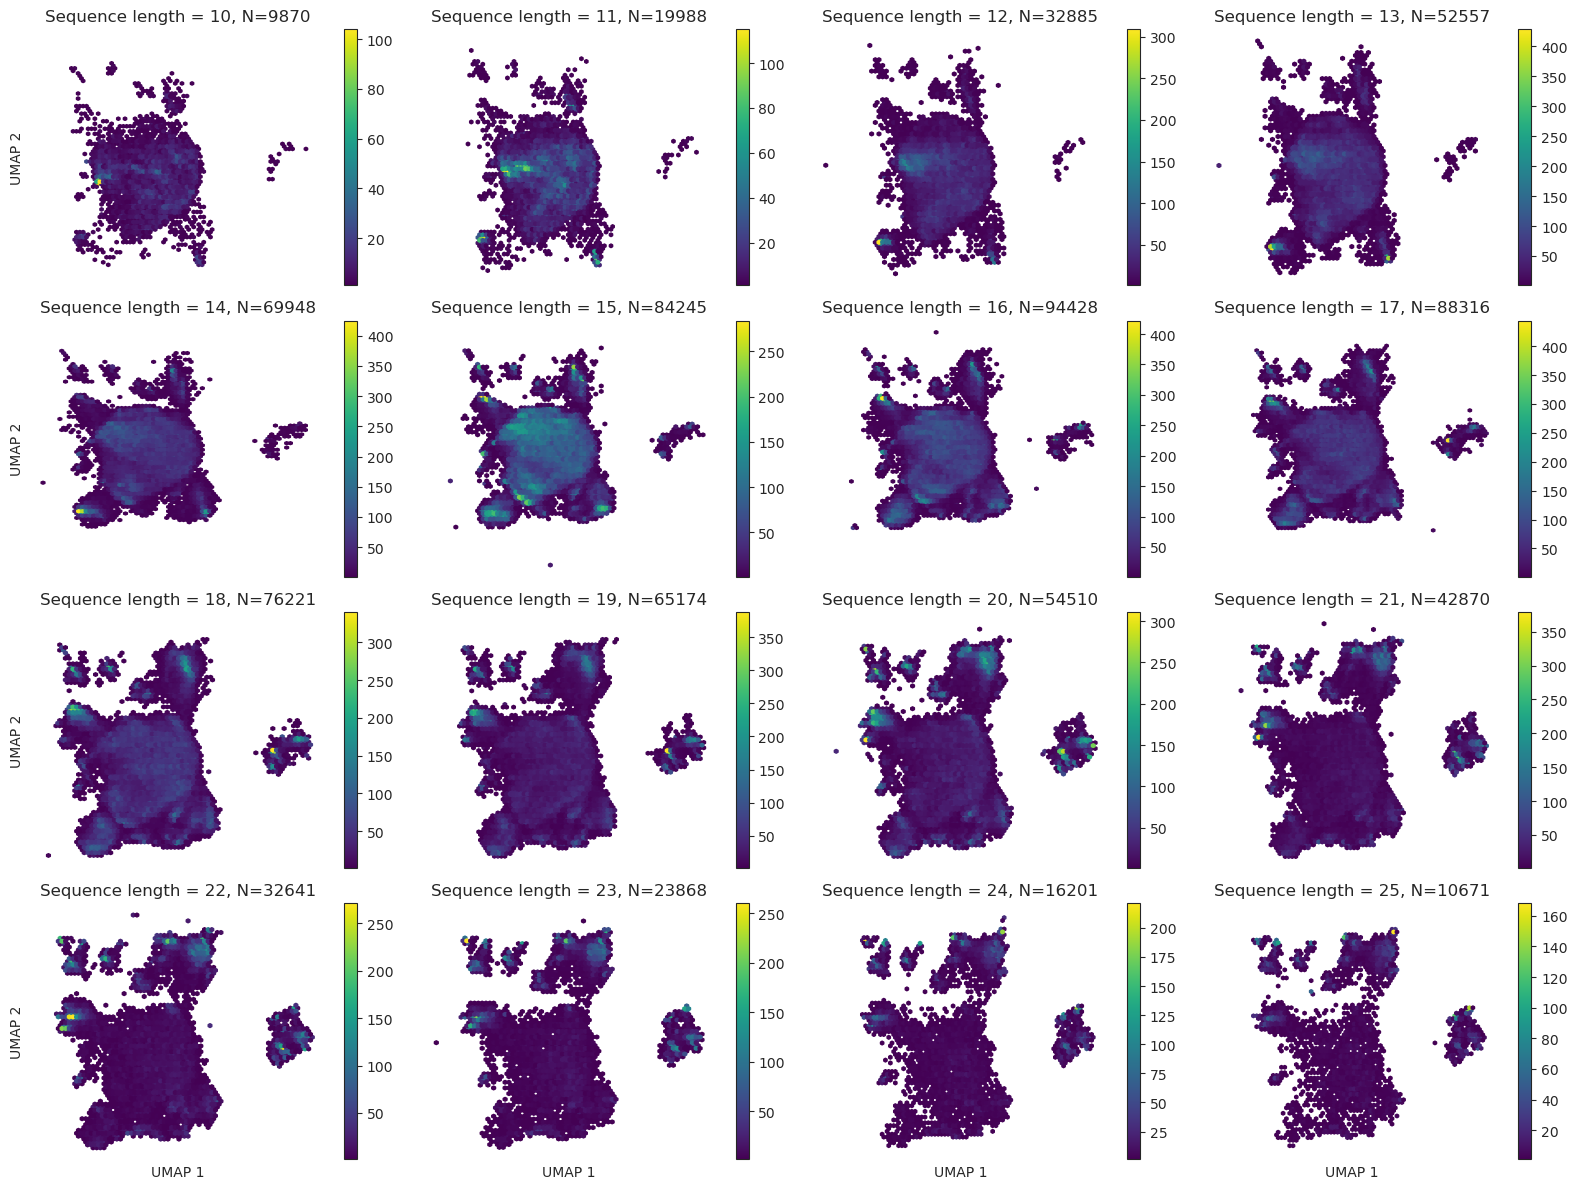

In [28]:
cutoff_values = np.arange(10, 26, 1)
label = 'junction_length'

x_dim = 4
y_dim = 4
alpha = 0.05
gridsize = 70  # Adjust the gridsize as needed

fig, axes = plt.subplots(y_dim, x_dim, figsize=(16, 12), sharex='col', sharey='row')

c = 0

# Loop through the cutoff values and create hexbin plots
for i in range(y_dim):
    for j in range(x_dim):
        cutoff = cutoff_values[c]
        c += 1

        ax = axes[i, j]
        x_data = ab2_df[ab2_df[label] == cutoff]['x']
        y_data = ab2_df[ab2_df[label] == cutoff]['y']

        hb = ax.hexbin(x_data, y_data, gridsize=gridsize, mincnt=1, cmap='viridis')
        num_data_points = len(x_data)
        ax.set_title(f'Sequence length = {cutoff}, N={num_data_points}', fontsize=12)
        plt.colorbar(hb, ax=ax)  # Add colorbar

        # Remove axis numbers and ticks
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xticklabels([])
        ax.set_yticklabels([])

# Add labels to the axes
for i in range(x_dim):
    axes[x_dim-1, i].set_xlabel('UMAP 1', fontsize=10)
    axes[i, 0].set_ylabel('UMAP 2', fontsize=10)

# Remove the spines
sns.despine(left=True, bottom=True)

# Adjust spacing between subplots
plt.tight_layout()

plt.savefig(f'{model_name}_ireceptor_hexbin_sep_by_{label}.png')

# Show the plot
plt.show()

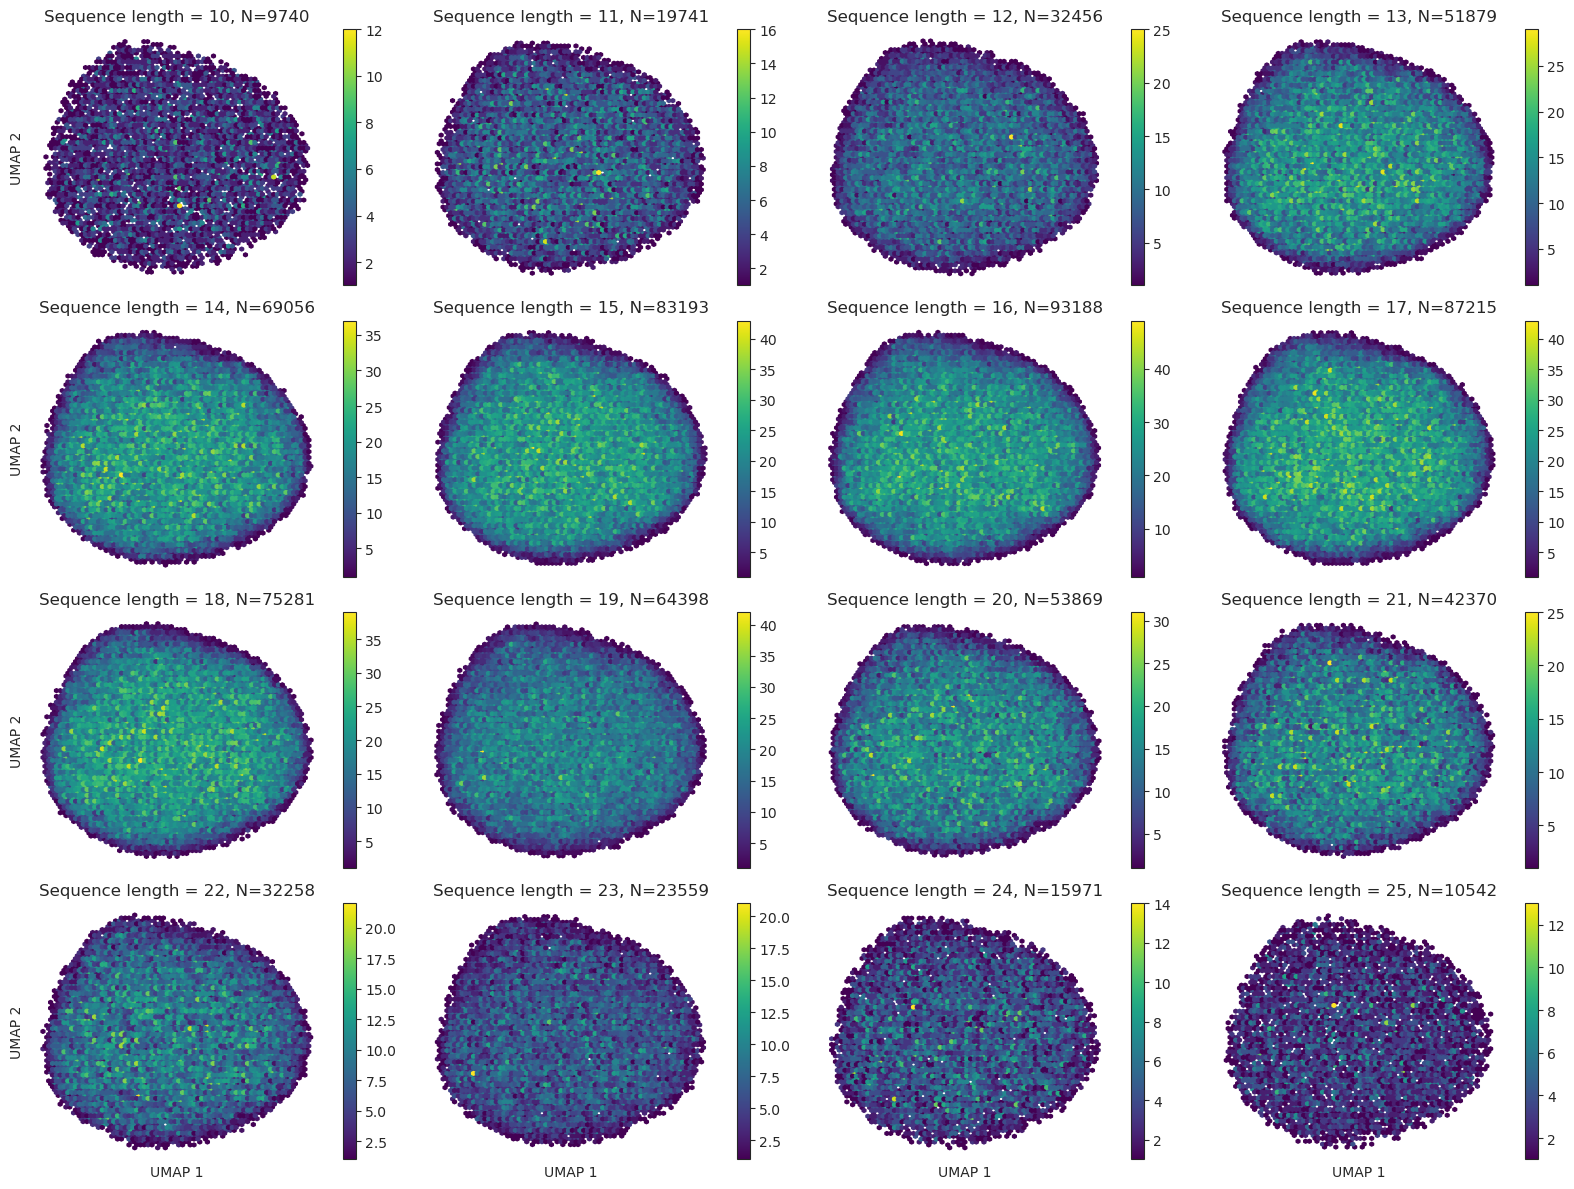

In [29]:
cutoff_values = np.arange(10, 26, 1)
label = 'junction_length'

x_dim = 4
y_dim = 4
alpha = 0.05
gridsize = 70  # Adjust the gridsize as needed

fig, axes = plt.subplots(y_dim, x_dim, figsize=(16, 12), sharex='col', sharey='row')

c = 0

# Loop through the cutoff values and create hexbin plots
for i in range(y_dim):
    for j in range(x_dim):
        cutoff = cutoff_values[c]
        c += 1

        ax = axes[i, j]
        x_data = ab2_random_df[ab2_random_df[label] == cutoff]['x']
        y_data = ab2_random_df[ab2_random_df[label] == cutoff]['y']

        hb = ax.hexbin(x_data, y_data, gridsize=gridsize, mincnt=1, cmap='viridis')
        num_data_points = len(x_data)
        ax.set_title(f'Sequence length = {cutoff}, N={num_data_points}', fontsize=12)
        plt.colorbar(hb, ax=ax)  # Add colorbar

        # Remove axis numbers and ticks
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xticklabels([])
        ax.set_yticklabels([])

# Add labels to the axes
for i in range(x_dim):
    axes[x_dim-1, i].set_xlabel('UMAP 1', fontsize=10)
    axes[i, 0].set_ylabel('UMAP 2', fontsize=10)

# Remove the spines
sns.despine(left=True, bottom=True)

# Adjust spacing between subplots
plt.tight_layout()

plt.savefig(f'{model_name}_random_hexbin_sep_by_{label}.png')

# Show the plot
plt.show()

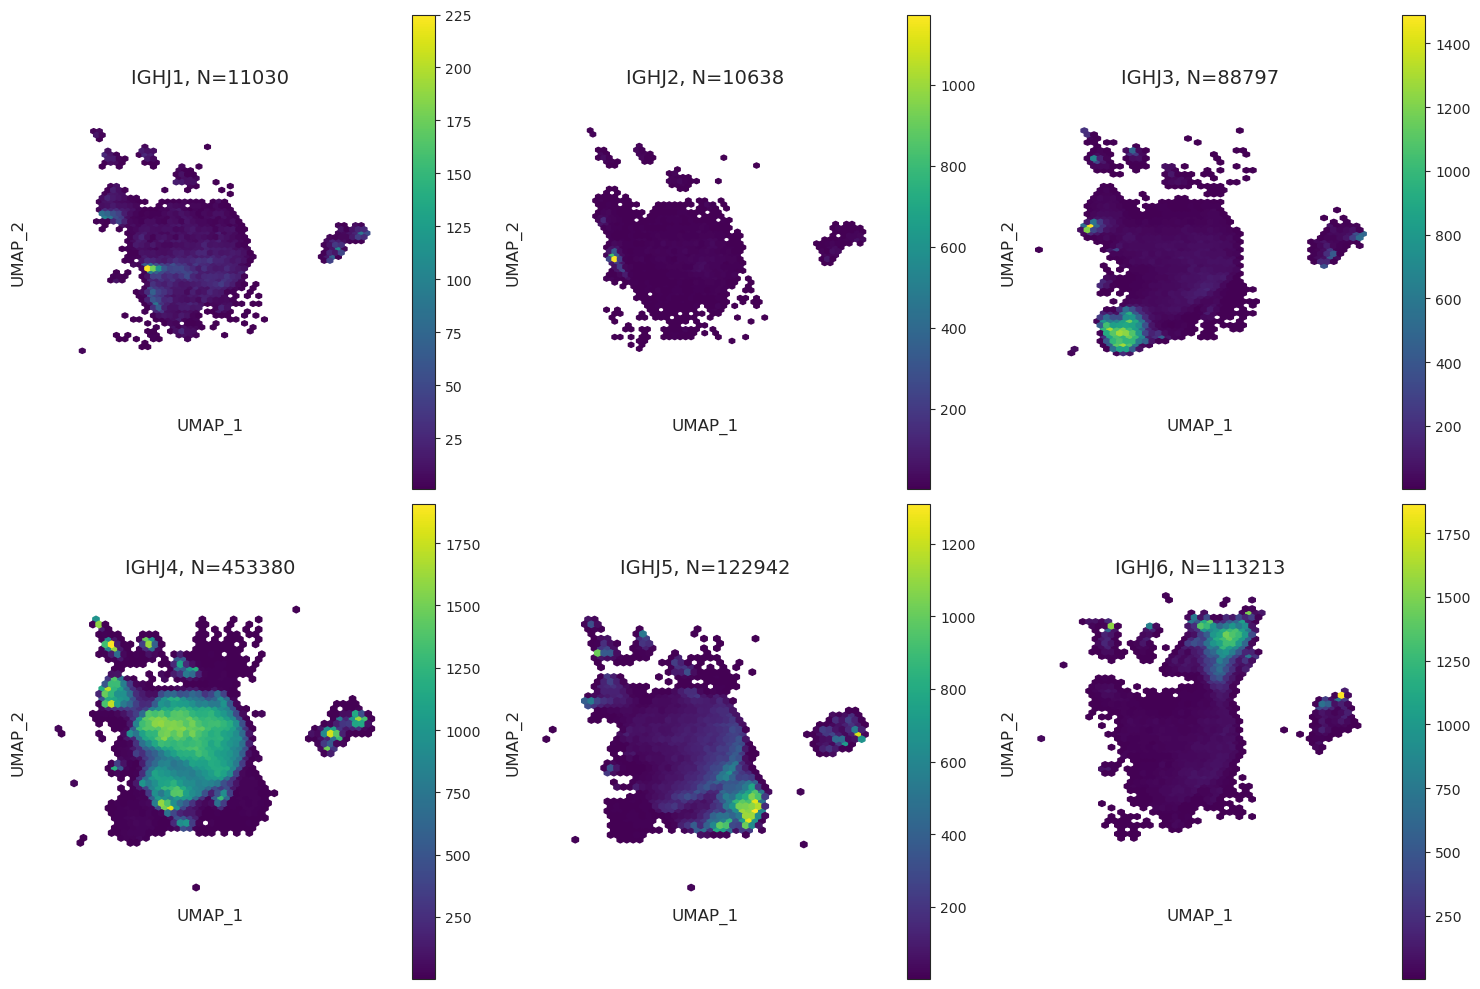

In [32]:
hue_name = 'j_family'  # column name for grouping
gridsize = 50

# --- Sort IGHV families in natural numeric order ---
# Extract the unique families and sort by their numeric suffix
unique_classes = sorted(
    esm2_df[hue_name].unique(),
    key=lambda x: int(''.join(filter(str.isdigit, x))) if any(ch.isdigit() for ch in x) else np.inf
)

# --- Grid layout ---
num_classes = len(unique_classes)
num_rows = int(num_classes ** 0.5)
num_cols = (num_classes + num_rows - 1) // num_rows

# --- Figure setup ---
fig_width = 20 if hue_name != 'j_family' else 20 * 3/4
fig_height = 20 * (num_rows / num_cols) if hue_name != 'j_family' else 20 * 3/4 * (num_rows / num_cols)
fig, axes = plt.subplots(num_rows, num_cols, figsize=(fig_width, fig_height), sharex=True, sharey=True)
axes = axes.flatten()

# --- Plot each V family ---
for i, el in enumerate(unique_classes):
    ax = axes[i]
    subset = ab2_df[ab2_df[hue_name] == el]
    x_data, y_data = subset['x'], subset['y']

    ax.set_aspect('equal')
    hb = ax.hexbin(x_data, y_data, gridsize=gridsize, mincnt=1, cmap='viridis')

    num_points = len(subset)
    ax.set_title(f'{el}, N={num_points}', fontsize=14)
    ax.set_xlabel('UMAP_1', fontsize=12)
    ax.set_ylabel('UMAP_2', fontsize=12)

    plt.colorbar(hb, ax=ax)

    # Remove axis numbers and ticks
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])

# Remove unused subplots
for i in range(num_classes, len(axes)):
    fig.delaxes(axes[i])

# Remove the spines
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig(f'{model_name}_ireceptor_hexbin_sep_by_{hue_name}.png', dpi=300)
plt.show()